# Model-Based Reinforcement Learning

So far, reinforcement learning has learned how to make decisions directly from
experience.

Value-based methods learn:

$$
Q_\theta(x,u),
$$

while policy-gradient methods learn:

$$
\pi_\theta(u|x).
$$

Model-Based Reinforcement Learning introduces another possibility:

$$
\boxed{
\text{Learn how the environment behaves}
}
$$

and then use that learned model for decision-making.

The central pipeline is:

$$
\boxed{
\text{Experience}
\rightarrow
\text{Learn Dynamics}
\rightarrow
\text{Plan}
\rightarrow
\text{Act}
}
$$

This connects reinforcement learning back to system identification and model
predictive control.

## Setup

Consider a simple vehicle with state:

$$
x_t=
\begin{bmatrix}
p_t\\
v_t
\end{bmatrix},
$$

and continuous control:

$$
u_t=a_t.
$$

The true environment evolves according to:

$$
p_{t+1}=
p_t+\Delta t\,v_t,
$$

$$
v_{t+1}=
v_t+\Delta t\,\theta u_t.
$$

The parameter:

$$
\theta
$$

represents actuator effectiveness.

The environment knows the true value of $\theta$, but the controller does not.

Our objective is to reach and maintain a desired velocity:

$$
v_{\mathrm{ref}}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DT = 0.1
TRUE_THETA = 0.7

V_REF = 5.0

U_MIN = -1.0
U_MAX = 1.0

In [2]:
def true_environment_step(state, action):

    position, velocity = state

    action = np.clip(
        action,
        U_MIN,
        U_MAX
    )

    next_position = (
        position
        + DT * velocity
    )

    next_velocity = (
        velocity
        + DT * TRUE_THETA * action
    )

    next_state = np.array([
        next_position,
        next_velocity
    ])

    reward = -(
        next_velocity - V_REF
    ) ** 2

    return next_state, reward

## 1. Model-Free vs Model-Based Reinforcement Learning

In model-free reinforcement learning, we do not explicitly learn the environment
dynamics.

For example, PPO learns:

$$
\boxed{
x_t
\rightarrow
\pi_\theta
\rightarrow
u_t
}
$$

directly from interaction.

The dynamics influence the experience collected by the agent, but the policy
does not explicitly represent:

$$
x_{t+1}=f(x_t,u_t).
$$

---

In Model-Based Reinforcement Learning, we explicitly learn a model:

$$
\boxed{
\hat x_{t+1}=
\hat f_\phi(x_t,u_t)
}
$$

from observed transitions:

$$
(x_t,u_t,x_{t+1}).
$$

The learned model can then be used to predict the consequences of candidate
actions.

The decision pipeline becomes:

$$
\boxed{
x_t
\rightarrow
\text{Learned Model}
\rightarrow
\text{Planning}
\rightarrow
u_t.
}
$$

## 2. Connection to System Identification

Model-Based RL begins with a problem that looks very similar to system
identification.

From observed transitions:

$$
(x_t,u_t,x_{t+1}),
$$

we estimate a model:

$$
\hat f_\phi(x_t,u_t)
\approx
x_{t+1}.
$$

In system identification, the main objective is often:

$$
\boxed{
\text{learn an accurate dynamics model}.
}
$$

In Model-Based RL, learning the model is not the final objective.

The model is learned because it will be used to make better decisions:

$$
\boxed{
\text{Learn Model}
\rightarrow
\text{Plan}
\rightarrow
\text{Act}
\rightarrow
\text{Collect New Experience}.
}
$$

Therefore, Model-Based RL combines model learning with a decision-making loop.

## 3. What Does the Dynamics Model Learn?

A dynamics model predicts how the state changes when an action is applied.

A deterministic model can represent:

$$
\boxed{
\hat x_{t+1}=
\hat f_\phi(x_t,u_t).
}
$$

Instead of predicting the complete next state, we can also predict the state
change:

$$
\boxed{
\Delta \hat x_t=
\hat f_\phi(x_t,u_t)
}
$$

and construct:

$$
\hat x_{t+1}=
x_t+\Delta\hat x_t.
$$

For stochastic systems, the model could instead represent a transition
distribution:

$$
p_\phi(x_{t+1}|x_t,u_t).
$$

In this notebook, we begin with a deterministic learned dynamics model.

## 4. Collecting Transition Data

The learned dynamics model requires transition data:

$$
\mathcal D=
\{
(x_t,u_t,x_{t+1})
\}.
$$

Each transition tells us:

> When the system was in state $x_t$ and action $u_t$ was applied, what happened
> next?

Initially, we can collect data using exploratory controls.

This gives us an initial dataset from which to estimate the dynamics.

In [3]:
def collect_transition_data(
    n_steps=500
):

    states = []
    actions = []
    next_states = []

    state = np.array([
        0.0,
        0.0
    ])

    for _ in range(n_steps):

        action = np.random.uniform(
            U_MIN,
            U_MAX
        )

        next_state, reward = (
            true_environment_step(
                state,
                action
            )
        )

        states.append(
            state.copy()
        )

        actions.append(
            action
        )

        next_states.append(
            next_state.copy()
        )

        state = next_state

    return (
        np.array(states),
        np.array(actions),
        np.array(next_states)
    )

In [4]:
states, actions, next_states = (
    collect_transition_data(
        n_steps=500
    )
)

print("States:", states.shape)
print("Actions:", actions.shape)
print("Next states:", next_states.shape)

States: (500, 2)
Actions: (500,)
Next states: (500, 2)


## 5. Learning a Simple Dynamics Model

For our vehicle:

$$
v_{t+1}=
v_t+\Delta t\,\theta u_t.
$$

Rearranging:

$$
v_{t+1}-v_t=
\Delta t\,\theta u_t.
$$

Define:

$$
y_t=
v_{t+1}-v_t
$$

and:

$$
\phi_t=
\Delta t\,u_t.
$$

Then:

$$
y_t=
\phi_t\theta.
$$

The unknown dynamics parameter can therefore be estimated using least squares:

$$
\boxed{
\hat\theta=
(\Phi^T\Phi)^{-1}\Phi^TY.
}
$$

In [5]:
Y = (
    next_states[:, 1]
    - states[:, 1]
)

Phi = (
    DT * actions
).reshape(-1, 1)

theta_hat = np.linalg.solve(
    Phi.T @ Phi,
    Phi.T @ Y
)

theta_hat = theta_hat.item()

print(
    "True theta:",
    TRUE_THETA
)

print(
    "Estimated theta:",
    theta_hat
)

True theta: 0.7
Estimated theta: 0.7


## 6. Constructing the Learned Dynamics Model

The estimated parameter:

$$
\hat\theta
$$

can now be inserted into a predictive model:

$$
\hat p_{t+1}=
p_t+\Delta t\,v_t,
$$

$$
\hat v_{t+1}=
v_t+\Delta t\,\hat\theta u_t.
$$

This model does not interact with the real environment.

Instead, it allows the controller to ask:

> What would happen if I applied this action?

That ability to simulate candidate futures is the key reason a learned model is
useful for planning.

In [6]:
def learned_dynamics(
    state,
    action,
    theta=theta_hat
):

    position, velocity = state

    next_position = (
        position
        + DT * velocity
    )

    next_velocity = (
        velocity
        + DT * theta * action
    )

    return np.array([
        next_position,
        next_velocity
    ])

## 7. Evaluating One-Step Predictions

Before planning with a learned model, we should evaluate its prediction quality.

For a transition:

$$
(x_t,u_t),
$$

the learned model predicts:

$$
\hat x_{t+1}=
\hat f(x_t,u_t).
$$

We can compare this with the actual environment transition:

$$
x_{t+1}.
$$

The prediction error is:

$$
\boxed{
e_t=
x_{t+1}-
\hat x_{t+1}.
}
$$

In [7]:
predicted_next_states = np.array([
    learned_dynamics(
        state,
        action
    )
    for state, action
    in zip(states, actions)
])

prediction_errors = (
    next_states
    - predicted_next_states
)

position_mae = np.mean(
    np.abs(
        prediction_errors[:, 0]
    )
)

velocity_mae = np.mean(
    np.abs(
        prediction_errors[:, 1]
    )
)

print(
    "Position MAE:",
    position_mae
)

print(
    "Velocity MAE:",
    velocity_mae
)

Position MAE: 0.0
Velocity MAE: 0.0


## 8. One-Step Accuracy Is Not Enough

A dynamics model may have very small one-step prediction error.

However, planning requires repeated application of the learned model:

$$
\hat x_{t+1}=
\hat f(\hat x_t,u_t),
$$

$$
\hat x_{t+2}=
\hat f(\hat x_{t+1},u_{t+1}),
$$

$$
\hat x_{t+3}=
\hat f(\hat x_{t+2},u_{t+2}),
$$

and so on.

Therefore, prediction errors can accumulate across the planning horizon.

This phenomenon is known as:

$$
\boxed{
\text{compounding model error}.
}
$$

A model that performs well for one-step prediction may still produce inaccurate
long-horizon rollouts.

## 9. Multi-Step Model Rollout

A planner uses the learned model repeatedly to simulate a candidate control
sequence:

$$
U=
\{u_t,u_{t+1},\ldots,u_{t+H-1}\}.
$$

Starting from the current state:

$$
x_t,
$$

the learned model predicts:

$$
\hat x_{t+1},
\hat x_{t+2},
\ldots,
\hat x_{t+H}.
$$

This predicted trajectory can then be evaluated using a control objective.

In [8]:
def rollout_learned_model(
    initial_state,
    control_sequence
):

    trajectory = [
        initial_state.copy()
    ]

    state = initial_state.copy()

    for action in control_sequence:

        state = learned_dynamics(
            state,
            action
        )

        trajectory.append(
            state.copy()
        )

    return np.array(
        trajectory
    )

In [9]:
control_sequence = np.ones(30)

predicted_trajectory = rollout_learned_model(
    initial_state=np.array([0.0, 0.0]),
    control_sequence=control_sequence
)

## 10. Planning With the Learned Model

Learning a dynamics model does not directly produce a controller.

The model only predicts:

$$
\hat x_{k+1}=
\hat f(\hat x_k,u_k).
$$

To choose actions, we need to evaluate candidate future control sequences.

Given:

$$
U=
\{u_t,u_{t+1},\ldots,u_{t+H-1}\},
$$

the learned model predicts a trajectory:

$$
\hat X=
\{\hat x_t,\hat x_{t+1},\ldots,\hat x_{t+H}\}.
$$

We then evaluate this predicted trajectory using a planning objective:

$$
J(U)=
\sum_{k=t}^{t+H-1}
\ell(\hat x_k,u_k)
+
\ell_f(\hat x_{t+H}).
$$

The planner searches for:

$$
\boxed{
U^*=
\arg\min_U J(U).
}
$$

The first action is executed in the real environment:

$$
u_t=U_0^*.
$$

## 11. Planning Objective

The planning objective should reflect the behavior we want from the vehicle.

For velocity tracking, define the stage cost:

$$
\ell(x_k,u_k)=
(v_k-v_{\mathrm{ref}})^2
+
\lambda_u u_k^2.
$$

The first term penalizes velocity-tracking error.

The second term penalizes excessive control effort.

Over a prediction horizon $H$:

$$
\boxed{
J(U)=
\sum_{k=0}^{H-1}
\left[
(v_k-v_{\mathrm{ref}})^2
+
\lambda_u u_k^2
\right].
}
$$

The planner searches for the control sequence that minimizes this predicted
future cost.

In [10]:
CONTROL_WEIGHT = 0.05


def planning_cost(
    initial_state,
    control_sequence
):

    state = initial_state.copy()

    total_cost = 0.0

    for action in control_sequence:

        state = learned_dynamics(
            state,
            action
        )

        velocity_error = (
            state[1] - V_REF
        )

        total_cost += (
            velocity_error ** 2
            + CONTROL_WEIGHT
            * action ** 2
        )

    return total_cost

## 12. Random-Shooting Planner

To keep the focus on Model-Based RL rather than optimization algorithms, we use
a simple sampling-based planner.

At the current state $x_t$:

1. Sample many candidate control sequences:

$$
U^{(1)},U^{(2)},\ldots,U^{(N)}.
$$

2. Predict the trajectory generated by each sequence using:

$$
\hat f.
$$

3. Evaluate each trajectory:

$$
J(U^{(i)}).
$$

4. Select:

$$
U^*=
\arg\min_{U^{(i)}}J(U^{(i)}).
$$

5. Execute only the first action:

$$
u_t=U_0^*.
$$

This is sometimes called a random-shooting planner.

In [11]:
def random_shooting_planner(
    state,
    horizon=15,
    n_candidates=500
):

    best_cost = np.inf
    best_sequence = None

    for _ in range(n_candidates):

        candidate_sequence = (
            np.random.uniform(
                U_MIN,
                U_MAX,
                size=horizon
            )
        )

        cost = planning_cost(
            state,
            candidate_sequence
        )

        if cost < best_cost:

            best_cost = cost
            best_sequence = (
                candidate_sequence
            )

    return (
        best_sequence,
        best_cost
    )

## 13. Receding-Horizon Execution

The planner predicts an entire optimal control sequence:

$$
U^*=
\{
u_t^*,
u_{t+1}^*,
\ldots,
u_{t+H-1}^*
\}.
$$

However, only:

$$
\boxed{
u_t=u_t^*
}
$$

is executed.

After observing the real next state:

$$
x_{t+1},
$$

the optimization problem is solved again.

Therefore:

$$
\boxed{
\text{Observe}
\rightarrow
\text{Plan}
\rightarrow
\text{Execute First Action}
\rightarrow
\text{Observe Again}.
}
$$

This is the same receding-horizon principle used in Model Predictive Control.

## 14. MPC With Learned Dynamics

We can now combine the learned dynamics model with receding-horizon planning.

At every real environment step:

$$
x_t
$$

is observed.

The planner uses:

$$
\hat f
$$

to solve:

$$
U^*=
\arg\min_U
J(U).
$$

Only:

$$
u_t=U_0^*
$$

is executed in the true environment.

The resulting architecture is:

$$
\boxed{
x_t
\rightarrow
\hat f
\rightarrow
\text{Planner}
\rightarrow
u_t
\rightarrow
\text{Real Environment}
\rightarrow
x_{t+1}.
}
$$

The learned model is therefore being used inside an MPC-style feedback loop.

In [12]:
def run_learned_model_mpc(
    n_steps=100,
    horizon=15,
    n_candidates=500
):

    state = np.array([
        0.0,
        0.0
    ])

    states_history = [
        state.copy()
    ]

    actions_history = []

    rewards_history = []

    for _ in range(n_steps):

        best_sequence, best_cost = (
            random_shooting_planner(
                state,
                horizon=horizon,
                n_candidates=n_candidates
            )
        )

        action = best_sequence[0]

        next_state, reward = (
            true_environment_step(
                state,
                action
            )
        )

        actions_history.append(
            action
        )

        rewards_history.append(
            reward
        )

        state = next_state

        states_history.append(
            state.copy()
        )

    return (
        np.array(states_history),
        np.array(actions_history),
        np.array(rewards_history)
    )

## 15. Evaluating the Learned-Model Controller

The controller plans using:

$$
\hat f,
$$

but actions are executed in the true environment:

$$
f.
$$

Successful control therefore requires the learned model to be sufficiently
accurate in the parts of the state-action space relevant to planning.

We evaluate the resulting closed-loop behavior using velocity tracking and
control effort.

In [13]:
mb_states, mb_actions, mb_rewards = (
    run_learned_model_mpc(
        n_steps=100,
        horizon=15,
        n_candidates=500
    )
)

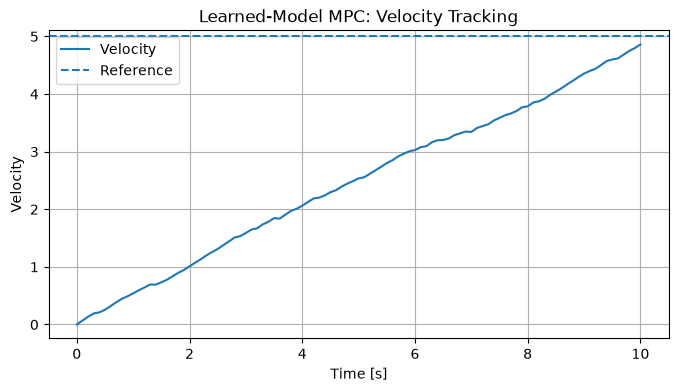

In [14]:
time = np.arange(
    len(mb_states)
) * DT

plt.figure(figsize=(8, 4))

plt.plot(
    time,
    mb_states[:, 1],
    label="Velocity"
)

plt.axhline(
    V_REF,
    linestyle="--",
    label="Reference"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity")

plt.title(
    "Learned-Model MPC: Velocity Tracking"
)

plt.legend()
plt.grid()
plt.show()

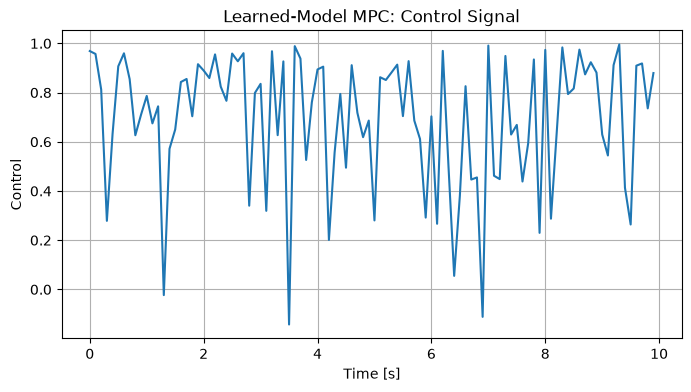

In [15]:
action_time = np.arange(
    len(mb_actions)
) * DT

plt.figure(figsize=(8, 4))

plt.plot(
    action_time,
    mb_actions
)

plt.xlabel("Time [s]")
plt.ylabel("Control")

plt.title(
    "Learned-Model MPC: Control Signal"
)

plt.grid()
plt.show()

## 16. From System Identification + MPC to Model-Based RL

So far, we have performed:

$$
\text{Collect Data}
\rightarrow
\text{Learn Model}
\rightarrow
\text{Plan}.
$$

This is closely related to:

$$
\boxed{
\text{System Identification}
+
\text{MPC}.
}
$$

Model-Based RL extends this idea by allowing interaction with the environment to
continually improve the model and therefore improve decision-making.

The complete loop becomes:

$$
\boxed{
\text{Collect Experience}
\rightarrow
\text{Update Model}
\rightarrow
\text{Plan}
\rightarrow
\text{Act}
\rightarrow
\text{Collect New Experience}.
}
$$

The model and the controller therefore improve through repeated interaction.

## 17. The Model-Based RL Interaction Loop

A model-based agent can repeatedly improve its internal dynamics model using new
experience.

Starting with a dataset:

$$
\mathcal D,
$$

the loop is:

$$
\boxed{
\mathcal D
\rightarrow
\hat f
\rightarrow
\text{Planning}
\rightarrow
u_t
\rightarrow
x_{t+1}
\rightarrow
\mathcal D
}
$$

The newly observed transition:

$$
(x_t,u_t,x_{t+1})
$$

is added to the dataset.

The model can then be updated:

$$
\hat f_{\phi_k}
\rightarrow
\hat f_{\phi_{k+1}}.
$$

Thus, experience improves the model and the improved model changes future
decisions.

## 18. Re-Estimating the Model

In [16]:
def estimate_theta(
    states,
    actions,
    next_states
):

    Y = (
        next_states[:, 1]
        - states[:, 1]
    )

    Phi = (
        DT * actions
    ).reshape(-1, 1)

    theta_hat = np.linalg.solve(
        Phi.T @ Phi + 1e-8 * np.eye(1),
        Phi.T @ Y
    )

    return theta_hat.item()

## 19. Exploration vs Control in Model-Based RL

A model-based agent needs informative data to learn accurate dynamics.

However, the actions that are best for controlling the system are not always the
actions that are most informative for learning the model.

For example, once the vehicle reaches:

$$
v_{\mathrm{ref}},
$$

a good controller may choose:

$$
u_t\approx0.
$$

But repeated observations with:

$$
u_t\approx0
$$

provide little information about actuator effectiveness.

This creates a trade-off:

$$
\boxed{
\text{Control Performance}
\quad\text{vs}\quad
\text{Information Gathering}.
}
$$

The agent may sometimes need exploratory actions to improve its model.

## 20. Planning Under Model Error

The planner optimizes predicted performance using the learned model:

$$
U^*=
\arg\min_U
J_{\hat f}(U).
$$

However, the real system evolves according to:

$$
f,
$$

not:

$$
\hat f.
$$

Therefore:

$$
J_{\hat f}(U)
$$

may differ from:

$$
J_f(U).
$$

A planner can even discover action sequences that appear excellent under the
learned model but perform poorly in the real environment.

Therefore, Model-Based RL must consider not only:

$$
\boxed{
\text{How well can we optimize the model?}
}
$$

but also:

$$
\boxed{
\text{Where can the model be trusted?}
}
$$

## 21. Distribution Shift

The learned model is accurate primarily in regions represented by its training
data.

Suppose the dataset contains:

$$
(x,u)\sim\mathcal D.
$$

During planning, the optimizer may propose states and actions outside this
distribution.

Then:

$$
\hat f(x,u)
$$

must extrapolate.

Prediction error can therefore increase when the planner visits unfamiliar
regions.

This creates a feedback loop:

$$
\text{Model Error}
\rightarrow
\text{Incorrect Planning}
\rightarrow
\text{New State Distribution}
\rightarrow
\text{Larger Model Error}.
$$

This is one of the central challenges of Model-Based Reinforcement Learning.

## 22. Model Uncertainty

A learned dynamics model may produce a prediction:

$$
\hat x_{t+1}=
\hat f_\phi(x_t,u_t),
$$

even for state-action pairs that are very different from its training data.

The prediction alone does not tell us whether the model is confident.

For planning, it can therefore be useful to represent both:

$$
\boxed{
\text{Prediction}
}
$$

and:

$$
\boxed{
\text{Uncertainty}.
}
$$

A model-based controller can then distinguish between:

$$
\text{predicted good behavior}
$$

and:

$$
\text{predicted good behavior in a region where the model is uncertain}.
$$

## 23. Model Ensembles

One way to estimate model uncertainty is to train multiple dynamics models:

$$
\hat f_1,
\hat f_2,
\ldots,
\hat f_M.
$$

For the same state-action pair:

$$
(x_t,u_t),
$$

each model predicts:

$$
\hat x_{t+1}^{(i)}=
\hat f_i(x_t,u_t).
$$

If the models make similar predictions, we have greater confidence in that
region.

If the predictions disagree strongly, the state-action pair may lie in a region
where the learned dynamics are uncertain.

Conceptually:

$$
\boxed{
\text{Ensemble Agreement}
\rightarrow
\text{Higher Confidence}
}
$$

$$
\boxed{
\text{Ensemble Disagreement}
\rightarrow
\text{Higher Model Uncertainty}
}
$$

## 24. Uncertainty-Aware Planning

Model uncertainty can be incorporated into the planning objective.

Instead of optimizing only predicted task cost:

$$
J_{\text{task}}(U),
$$

we can also penalize uncertain predictions:

$$
\boxed{
J(U)=
J_{\text{task}}(U)
+
\beta J_{\text{uncertainty}}(U).
}
$$

The parameter:

$$
\beta
$$

controls how cautious the planner is.

This encourages the controller to prefer trajectories where the learned model
is more reliable.

However, excessive uncertainty avoidance can also prevent exploration.

Therefore, Model-Based RL contains another trade-off:

$$
\boxed{
\text{Avoid Uncertain Regions}
\quad\text{vs}\quad
\text{Explore Uncertain Regions to Learn}.
}
$$

## 25. Why Receding-Horizon Planning Helps With Model Error

Long learned-model rollouts can accumulate prediction error:

$$
\hat x_{t+1}
\rightarrow
\hat x_{t+2}
\rightarrow
\cdots
\rightarrow
\hat x_{t+H}.
$$

As the horizon grows, later predictions may become increasingly inaccurate.

Receding-horizon control reduces this problem.

Instead of executing the entire predicted sequence:

$$
u_t^*,
u_{t+1}^*,
\ldots,
u_{t+H-1}^*,
$$

we execute only:

$$
u_t^*.
$$

We then observe the actual next state:

$$
x_{t+1},
$$

and replan.

Therefore:

$$
\boxed{
\text{Prediction}
\rightarrow
\text{One Real Action}
\rightarrow
\text{Real Observation}
\rightarrow
\text{Replan}
}
$$

repeatedly corrects the planner using real system feedback.

## 26. Model-Based vs Model-Free Reinforcement Learning

Model-free and model-based RL learn different intermediate representations.

### Model-Free RL

For example, PPO learns:

$$
\pi_\theta(u|x).
$$

The deployment pipeline is:

$$
\boxed{
x_t
\rightarrow
\pi_\theta
\rightarrow
u_t.
}
$$

No explicit dynamics model is required for action selection.

---

### Model-Based RL

Model-Based RL learns:

$$
\hat f_\phi(x,u)
\approx
x'.
$$

The controller then uses the learned model for planning:

$$
\boxed{
x_t
\rightarrow
\hat f_\phi
\rightarrow
\text{Planner}
\rightarrow
u_t.
}
$$

Therefore, the model-based agent explicitly reasons about predicted future
consequences before selecting an action.

### Model-Free PPO vs Model-Based RL

| Aspect | Model-Free PPO | Model-Based RL |
|---|---|---|
| **What is learned?** | Policy $\pi_\theta(u\mid x)$ and value function $V_\phi(x)$ | Dynamics model $\hat f_\phi(x,u)$ |
| **Main idea** | Learn directly which action to take | Learn how the environment behaves, then plan actions |
| **Dynamics model required?** | No explicit dynamics model | Yes, dynamics are explicitly learned |
| **Decision pipeline** | $x \rightarrow \pi_\theta \rightarrow u$ | $x \rightarrow \hat f_\phi \rightarrow \text{Planning} \rightarrow u$ |
| **Future prediction** | Not explicitly required | Explicitly predicts future states |
| **Planning at deployment** | Usually no | Usually yes |
| **Online optimization** | Usually no; policy inference is enough | Often yes; planner/MPC solves an optimization problem |
| **Environment interaction** | Used to directly improve policy/value functions | Used to improve the dynamics model |
| **Data efficiency** | Often requires more real interactions | Can be more data-efficient because the model allows imagined rollouts |
| **Main source of error** | Policy/value estimation and optimization errors | Model error, model bias, and planning error |
| **Distribution shift** | Policy may encounter states poorly represented during training | Planner may exploit regions where the learned model has little training data |
| **Uncertainty** | Not explicitly represented by standard PPO | Can explicitly model dynamics uncertainty, e.g. using ensembles |
| **Constraints** | Not naturally enforced by basic PPO | Can be explicitly included in the planner/MPC |
| **Computation during training** | Potentially expensive due to environment interaction | Model learning + planning can be computationally expensive |
| **Computation during deployment** | Usually cheap: one neural-network forward pass | Usually higher because planning is performed online |
| **Connection to classical control** | Less direct | Strong connection to System Identification + MPC |
| **Typical strength** | Complex behaviors can be learned without an explicit dynamics model | Planning, data efficiency, interpretability, and reuse of control methods |
| **Typical weakness** | Sample inefficiency and limited explicit constraint handling | Learned-model inaccuracies can lead to poor or unsafe plans |

#### Mental Model

Model-Free PPO:

$$
\boxed{
\text{Experience}
\rightarrow
\text{Policy Learning}
\rightarrow
\pi_\theta(u|x)
\rightarrow
u
}
$$

Model-Based RL:

$$
\boxed{
\text{Experience}
\rightarrow
\text{Model Learning}
\rightarrow
\hat f_\phi(x,u)
\rightarrow
\text{Planning}
\rightarrow
u
}
$$

The fundamental difference is therefore:

$$
\boxed{
\text{PPO learns what to do directly}
}
$$

while:

$$
\boxed{
\text{Model-Based RL learns what will happen and uses that knowledge to decide what to do.}
}
$$

## 27. Why Model-Based RL Can Be Data Efficient?

Real environment interaction can be expensive.

Model-Based RL attempts to extract additional information from each real
transition by learning:

$$
\hat f_\phi(x,u).
$$

Once the model has been learned, the agent can evaluate many candidate futures
inside the model:

$$
\hat x_{t+1},
\hat x_{t+2},
\ldots
$$

without executing every candidate action sequence in the real environment.

Conceptually:

$$
\boxed{
\text{Real Experience}
\rightarrow
\text{Learn Model}
\rightarrow
\text{Many Imagined Futures}.
}
$$

This can improve data efficiency compared with purely model-free interaction.

## 28. The Fundamental Model-Based RL Trade-Off

A learned model provides the ability to predict and plan.

This can make learning more data efficient.

However, planning relies on:

$$
\hat f
$$

rather than the true dynamics:

$$
f.
$$

Therefore:

$$
\boxed{
\text{Better use of data}
}
$$

comes with:

$$
\boxed{
\text{risk of model bias and model exploitation}.
}
$$

The central challenge is not simply learning a model with low training error.

The model must be sufficiently accurate in the regions that the planner intends
to visit.

## 29. From System Identification to Model-Based RL

The relationship between the earlier notebooks can now be summarized as:

```text
Unknown Physical System
        │
        │  collect transitions
        ▼
(x_t, u_t, x_{t+1})
        │
        ▼
System Identification
        │
        │  learn dynamics
        ▼
      f_hat
        │
        ▼
      MPC
        │
        │  predict candidate futures
        │  optimize control sequence
        ▼
      u_t
        │
        ▼
Real Environment
        │
        │  observe new transition
        ▼
(x_t, u_t, x_{t+1})
        │
        └──────────────► update model

## 30. The Learning-Based Control Map

The learning-based control methods studied in the final notebooks can be
organized by **what is learned**.

```text
                         EXPERIENCE
                             │
           ┌─────────────────┼──────────────────┐
           │                 │                  │
           ▼                 ▼                  ▼
     Learn Model        Learn Value        Learn Policy
           │                 │                  │
           ▼                 ▼                  ▼
       f_hat(x,u)         Q(x,u)            π(u|x)
           │                 │                  │
           ▼                 ▼                  │
       Planning          argmax Q               │
           │                 │                  │
           ▼                 ▼                  ▼
         Action            Action             Action
           │                                    │
           │                                    │
           ▼                                    ▼
   Model-Based RL                       Policy Gradient
                                               │
                                               ▼
                                         Actor-Critic
                                               │
                                               ▼
                                              PPO


That map is more valuable to remember than the details of every update equation.

---

## 31. From Optimal Control to Reinforcement Learning

The entire project can now be viewed as a progression in what information is
available and what must be learned.

### Known Dynamics + Known Objective

Use optimal control:

$$
\boxed{
f + J
\rightarrow
\text{Optimization}
\rightarrow
u
}
$$

Examples:

- trajectory optimization,
- iLQR,
- MPC.

---

### Unknown Dynamics

Learn:

$$
\hat f
$$

using system identification.

Then control using:

$$
\hat f.
$$

---

### Expert Demonstrations Available

Learn:

$$
\pi_\theta(u|x)
$$

using imitation learning.

---

### Reward Available but Expert Policy Unknown

Learn through interaction using reinforcement learning.

Value-based methods learn:

$$
Q(x,u).
$$

Policy-gradient methods learn:

$$
\pi_\theta(u|x).
$$

---

### Unknown Dynamics + Planning Through Experience

Learn:

$$
\hat f(x,u)
$$

and use the learned model for decision-making.

This gives Model-Based Reinforcement Learning.

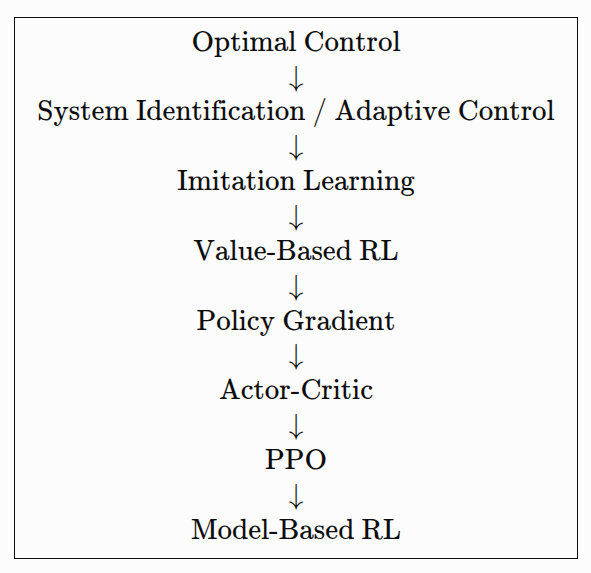

## 32. Model-Based Reinforcement Learning — Summary

Model-Based Reinforcement Learning explicitly learns a dynamics model:

$$
\boxed{
\hat x_{t+1}=
\hat f_\phi(x_t,u_t).
}
$$

The model is learned from experience:

$$
(x_t,u_t,x_{t+1}).
$$

Unlike system identification alone, the learned model is used as part of a
decision-making loop:

$$
\boxed{
\text{Experience}
\rightarrow
\text{Learn Model}
\rightarrow
\text{Plan}
\rightarrow
\text{Act}
\rightarrow
\text{New Experience}.
}
$$

Planning can be performed using methods such as MPC:

$$
U^*=
\arg\min_U
J_{\hat f}(U).
$$

Only the first action is executed:

$$
u_t=U_0^*,
$$

after which the real state is observed and planning is repeated.

Important challenges include:

- compounding model error,
- distribution shift,
- insufficient excitation,
- model uncertainty,
- model exploitation,
- the exploration vs control trade-off.

Model ensembles can provide an estimate of uncertainty by measuring disagreement
between learned models.

Receding-horizon planning helps reduce the effect of long-horizon model error by
repeatedly correcting predictions using real observations.

The key distinction from model-free RL is:

$$
\boxed{
\text{Model-Free RL}
:
x
\rightarrow
\pi_\theta
\rightarrow
u
}
$$

versus:

$$
\boxed{
\text{Model-Based RL}
:
x
\rightarrow
\hat f_\phi
\rightarrow
\text{Planning}
\rightarrow
u.
}
$$

The central connection to earlier notebooks is:

$$
\boxed{
\text{System Identification}
+
\text{Planning}
+
\text{Interaction}
\rightarrow
\text{Model-Based RL}.
}
$$